# HOTEL BOOKING ANALYSIS

## Dataset Overview

The dataset contains booking transactions from an online hotel reservation platform.

Key attributes include:
- Customer and property identifiers
- Hotel star rating and city
- Booking channel (Web, Mobile App, Travel Agent)
- Room type and booking value
- Booking status (Confirmed, Cancelled, Failed)
- Travel dates and payment details

The analysis aims to identify booking trends, understand cancellation behavior, and provide business recommendations.

In [637]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [638]:
#Loading the dataset
df = pd.read_csv("Hotel_bookings_final.csv")

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, quality, and characteristics of the dataset before conducting deeper analysis.

This includes:
- Understanding dataset dimensions
- Inspecting column data types
- Examining summary statistics
- Identifying missing values

In [639]:
#Checking the shape of the dataset
df.shape

(30000, 24)

In [640]:
#Checking the first 5 rows of the dataset
df.head(5)

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,Mobile App,19361.0,19361,5981,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,Mobile App,6137.0,6137,1896,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,Web,22702.0,22702,7013,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,Web,34068.0,34068,10524,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,Mobile App,12127.0,12127,3746,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [641]:
#Checking the columns of the dataset
df.columns

Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?'],
      dtype='object')

In [642]:
#Checking the data types and missing values in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [643]:
df.describe()

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


## Missing Value Analysis

Missing values were checked across all columns to identify potential data quality issues.

The analysis shows that most columns do not contain missing values. However, the **check_in_date** and **check_out_date** columns contain missing entries. These missing values correspond to bookings that were cancelled or failed before travel dates were assigned.

Instead of removing these records entirely, they are retained for booking and cancellation analysis. Missing travel dates only affect calculations related to stay duration.

In [644]:
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64

In [645]:
df.duplicated().sum()


np.int64(0)

## Data Cleaning

The dataset was examined for missing values and data type inconsistencies.  
Date columns were converted to datetime format to enable temporal analysis.

Missing check-in and check-out dates occur because some bookings were cancelled or failed before travel dates were assigned.

In [646]:
# convert date columns
df["booking_date"] = pd.to_datetime(df["booking_date"], errors="coerce")
df["check_in_date"] = pd.to_datetime(df["check_in_date"], errors="coerce")
df["check_out_date"] = pd.to_datetime(df["check_out_date"], errors="coerce")



## Feature Engineering

New variables were created to support further analysis:

- **stay_length**: number of days between check-in and check-out
- **booking_month**: extracted from booking_date for seasonal analysis
- **booking_year**: extracted to analyze trends over time

In [647]:
# create stay length
df["stay_length"] = (df["check_out_date"] - df["check_in_date"]).dt.days

# create month/year
df["booking_month"] = df["booking_date"].dt.month
df["booking_year"] = df["booking_date"].dt.year

## Booking Status Distribution

This section analyzes the distribution of booking outcomes such as confirmed, cancelled, and failed bookings.  
Understanding the proportion of cancellations helps identify operational inefficiencies.

In [648]:
# Booking Status Distribution
df['booking_status'].value_counts()


booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64

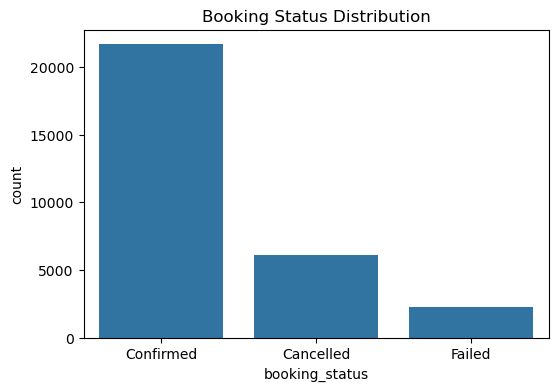

In [649]:
plt.figure(figsize=(6,4))
sns.countplot(x='booking_status', data=df)
plt.title("Booking Status Distribution")
plt.show()

## Booking Channel Analysis

This analysis evaluates how bookings are distributed across different booking channels such as Web, Mobile App, and Travel Agent.

The goal is to understand which channels contribute the most bookings and revenue.

In [650]:
# Booking Channels
df['booking_channel'].value_counts()

booking_channel
Web             15001
Mobile App      12009
Travel Agent     2990
Name: count, dtype: int64

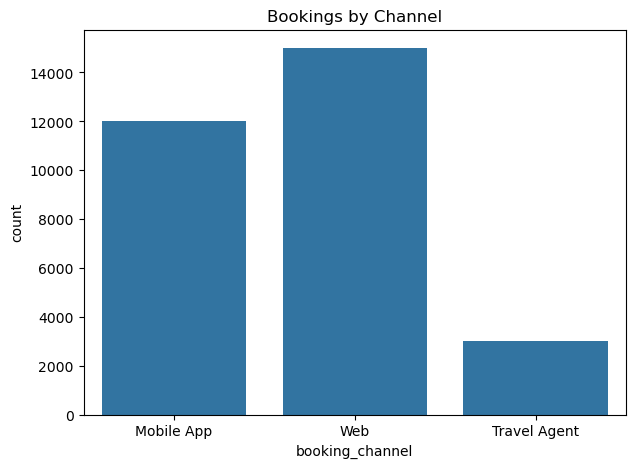

In [651]:
plt.figure(figsize=(7,5))
sns.countplot(x='booking_channel', data=df)
plt.title("Bookings by Channel")
plt.show()

**Observation:**  
The Web channel shows a slightly higher median booking value compared to Mobile App and Travel Agent channels. This suggests that customers booking through the website may spend more per booking.

## Hotel Star Rating Analysis

This analysis explores booking distribution across hotels with different star ratings.  
It helps identify whether customers prefer budget, mid-range, or luxury accommodations.

In [652]:
#Star Rating Analysis
df['star_rating'].value_counts().sort_index()

star_rating
2     2995
3    10460
4    12034
5     4511
Name: count, dtype: int64

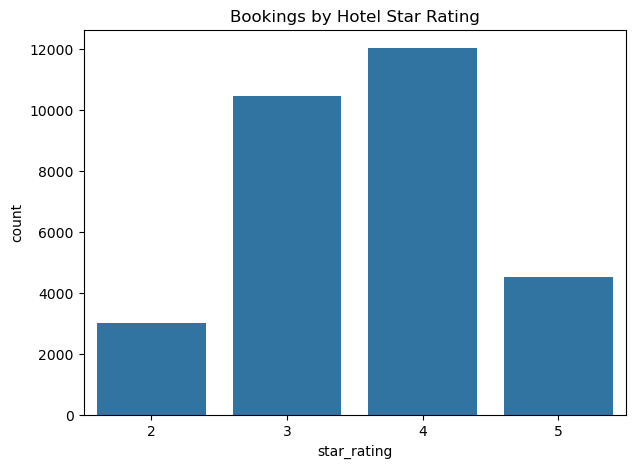

In [653]:
plt.figure(figsize=(7,5))
sns.countplot(x='star_rating', data=df)
plt.title("Bookings by Hotel Star Rating")
plt.show()

## Room Type Analysis

This section examines customer preferences for different room types such as Standard, Deluxe, and Suite rooms. Understanding room demand can help identify opportunities for upselling higher-value room categories.

In [654]:
#Room Type Distribution
df['room_type'].value_counts()

room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64

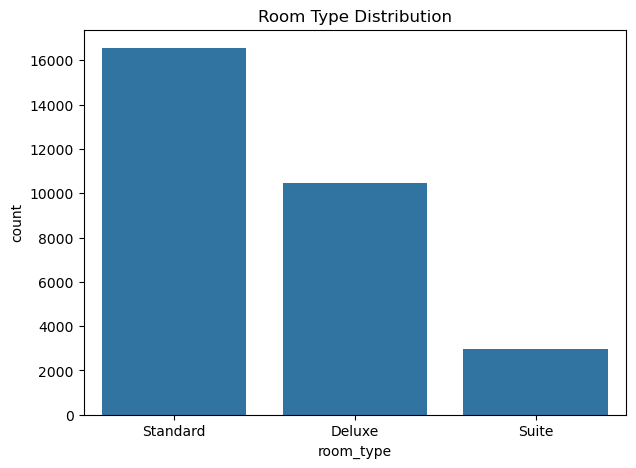

In [655]:
plt.figure(figsize=(7,5))
sns.countplot(x='room_type', data=df)
plt.title("Room Type Distribution")
plt.show()

**Observation:**  
Standard rooms appear to have the highest number of bookings, indicating that customers generally prefer more affordable accommodation options. Premium room types such as Deluxe and Suite are booked less frequently but may generate higher booking values.

## Booking Value Distribution

This section examines the distribution of **booking values** across all reservations in the dataset.

Analyzing booking value distribution helps understand:
- The typical price range customers pay for hotel bookings
- Whether the dataset contains mostly budget, mid-range, or premium bookings
- The presence of any unusually high or low booking values

Understanding this distribution provides insight into customer spending behavior and helps identify opportunities for pricing optimization.

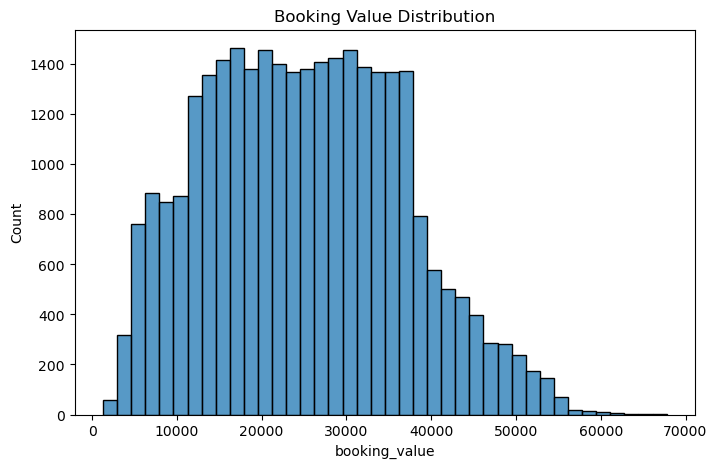

In [656]:
#Booking Value Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['booking_value'], bins=40)
plt.title("Booking Value Distribution")
plt.show()

## Booking Value by Booking Channel

This analysis compares the **average booking value across different booking channels** such as Web, Mobile App, and Travel Agent.

The objective is to determine whether certain channels generate higher-value bookings than others.

Insights from this analysis can help:
- Identify the most profitable booking channels
- Optimize marketing investments across channels
- Develop targeted promotions for high-value customer segments.

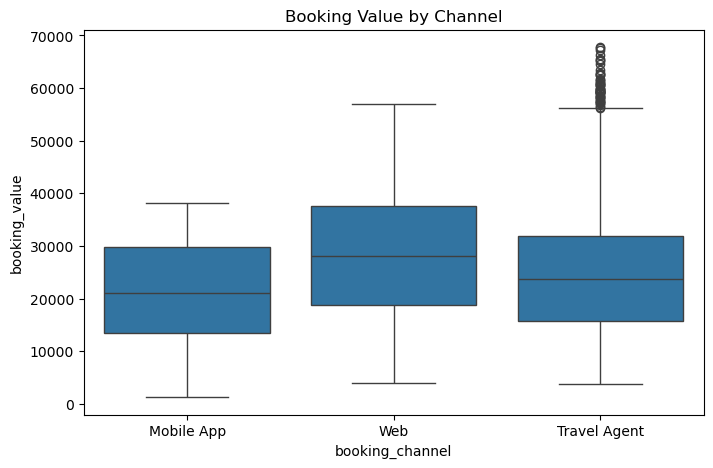

In [657]:
# Booking Value by Channel
plt.figure(figsize=(8,5))
sns.boxplot(x='booking_channel', y='booking_value', data=df)
plt.title("Booking Value by Channel")
plt.show()

**Observation:**  
From the visualization, bookings made through the **Web channel generally show higher median booking values compared to Mobile App and Travel Agent channels.** This suggests that customers booking through the website may tend to spend slightly more per booking.

The **Mobile App channel shows comparatively lower booking values**, indicating that mobile users may be booking more budget-friendly options or shorter stays.

The **Travel Agent channel shows a wider spread of booking values with several high-value outliers**, which suggests that some bookings through agents involve premium hotels or larger bookings.

Overall, while all channels contribute significantly to bookings, the **Web channel appears to generate slightly higher-value bookings on average.**

## Booking Value by Star Rating

This section analyzes the relationship between **hotel star ratings and booking values**.

Higher star-rated hotels typically offer premium services and amenities, which may influence customers to spend more per booking.

The visualization compares booking value distributions across different star ratings to determine:

- Whether premium hotels generate higher booking values
- The spread of booking prices across hotel categories
- The presence of high-value outliers in luxury hotel bookings

Understanding this relationship helps identify which hotel segments contribute most to revenue and where promotional strategies could be targeted.

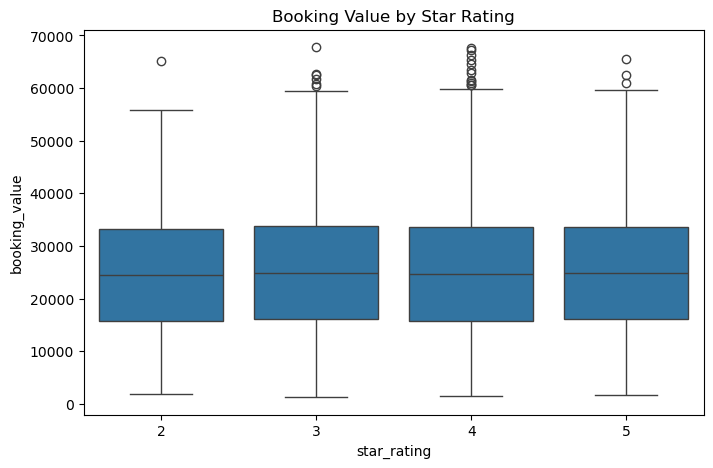

In [658]:
# Booking Value by star rating
plt.figure(figsize=(8,5))
sns.boxplot(x='star_rating', y='booking_value', data=df)
plt.title("Booking Value by Star Rating")
plt.show()

**Observation:**  
Higher star-rated hotels generally show higher booking values compared to lower-rated properties. This suggests that customers choosing premium hotels tend to spend more on their bookings.

## Stay Length Distribution

This section analyzes the distribution of **customer stay durations** across hotel bookings.

The stay_length feature represents the number of days between check-in and check-out dates. Understanding stay duration patterns helps identify whether customers primarily book short trips, weekend stays, or extended vacations.

Insights from this analysis can help the platform:

- Optimize pricing strategies for short and long stays
- Design promotional offers for extended bookings
- Better understand customer travel behavior.

The histogram visualization highlights how frequently different stay durations occur in the dataset.

In [659]:
df['stay_length'].value_counts()

stay_length
6.0    3549
1.0    3528
3.0    3520
5.0    3512
7.0    3506
4.0    3489
2.0    3428
Name: count, dtype: int64

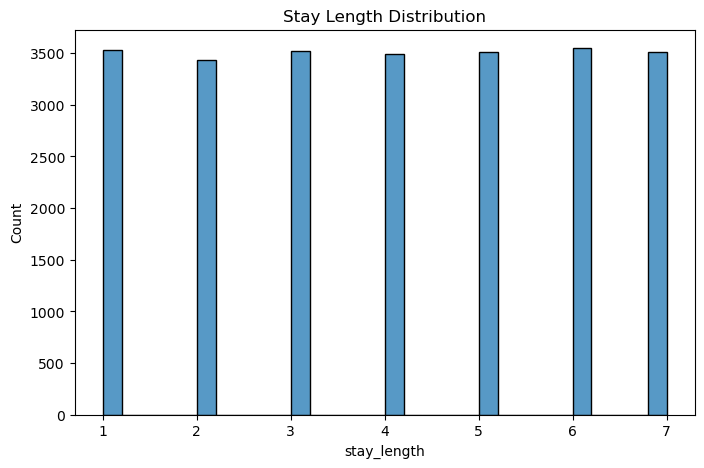

In [660]:
#Stay Length Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['stay_length'], bins=30)
plt.title("Stay Length Distribution")
plt.show()

**Observation:**  
Most customers appear to book shorter stays, indicating that the platform is commonly used for short trips, weekend travel, or business visits rather than long vacations.

## Monthly Booking Analysis

In this section, we look at how the number of hotel bookings changes from month to month.

Travel demand often changes during the year because of holidays, vacation seasons, weather conditions, and special events. By studying monthly booking patterns, we can understand when people are more likely to travel and book hotels.

This analysis helps identify busy travel months as well as quieter periods. These insights can help the platform plan better promotions, pricing strategies, and marketing campaigns during different times of the year.

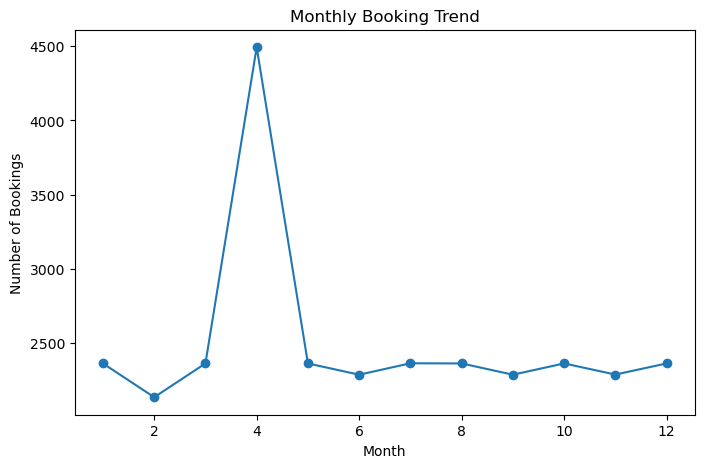

In [661]:
#Monthly Booking Trends
monthly_bookings = df.groupby('booking_month').size()

monthly_bookings.plot(kind='line', marker='o', figsize=(8,5))

plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.show()

**Observation:**  
Bookings remain fairly consistent across most months, indicating stable demand for hotel reservations throughout the year. However, there is a significant spike in **April**, suggesting a peak travel period during this month. This could be driven by holiday seasons, school vacations, or increased travel activity. Understanding these seasonal patterns can help the platform plan targeted promotions and optimize pricing strategies during high-demand periods.

## Cancellation Analysis

In this section, we analyze how many bookings were cancelled compared to the total number of bookings.

Cancellations are important for a hotel booking platform because they can lead to lost revenue and unused hotel inventory. By studying cancellation patterns, we can better understand customer behavior and identify possible reasons why bookings do not result in completed stays.

This analysis helps highlight the overall cancellation rate and allows us to explore where cancellations are occurring. Understanding these patterns can help the platform develop strategies to reduce cancellations and improve booking reliability.

In [662]:

cancelled = df[df['booking_status']=="Cancelled"]
cancelled.shape


(6070, 27)

In [663]:
#Cancellation Rate
cancelled = df[df["booking_status"] == "Cancelled"]

cancel_rate = (cancelled.shape[0] / df.shape[0]) * 100

print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancellation Rate: 20.23%


**Observation:**  
Around 20% of the bookings in the dataset were cancelled, meaning roughly one out of every five bookings did not result in a completed stay. This indicates a significant opportunity to reduce cancellations through improved booking policies or incentives.

## Cancellation by Booking Channel

In this section, we look at how cancellations are distributed across different booking channels such as Web, Mobile App, and Travel Agent.

Different booking channels may attract different types of customers, and their booking behavior can vary. For example, customers booking through mobile apps may cancel more often because it is quick and easy to compare options and make changes.

By analyzing cancellations by channel, we can understand which platforms experience higher cancellation rates and identify areas where the booking process or cancellation policies may need improvement.

In [664]:
#Cancellation By Channel
pd.crosstab(df['booking_channel'], df['booking_status'])

booking_status,Cancelled,Confirmed,Failed
booking_channel,,,
Mobile App,2589,8111,1309
Travel Agent,835,1979,176
Web,2646,11582,773


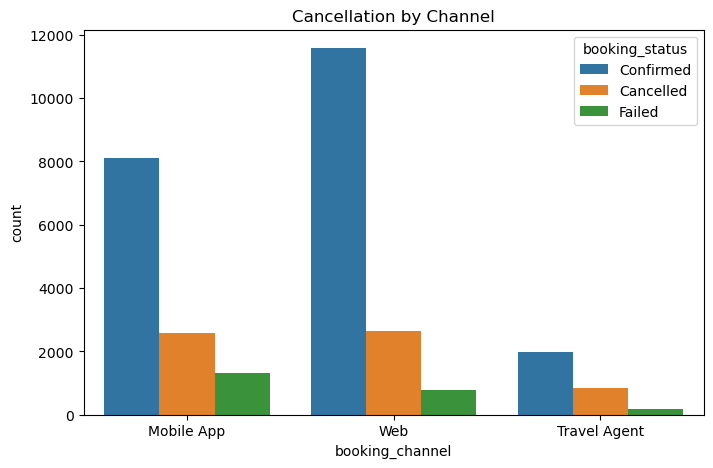

In [665]:
plt.figure(figsize=(8,5))
sns.countplot(x='booking_channel', hue='booking_status', data=df)
plt.title("Cancellation by Channel")
plt.show()

## Profitability Analysis

In this section, we analyze how much profit is generated from each booking. Profit is calculated by subtracting the **cost price** from the **selling price** of the booking.

Understanding profitability helps identify which types of bookings contribute the most value to the platform.

The analysis shows that the **average profit per booking is approximately 6,963**.

We also compared the average profit across different room types:

- Standard rooms generate an average profit of around **6980**
- Suite rooms generate an average profit of around **6979**
- Deluxe rooms generate an average profit of around **6932**

The results show that profit margins are relatively similar across room types, although **Standard and Suite rooms generate slightly higher average profit compared to Deluxe rooms**.

This insight suggests that promoting Standard and Suite room bookings may help maintain strong profitability while still meeting customer demand.

In [666]:
#profitability analysis
df['profit'] = df['selling_price'] - df['costprice']

In [667]:
#Average Profit
df['profit'].mean()

np.float64(6963.3244)

In [668]:
#Profit By room type
df.groupby('room_type')['profit'].mean()

room_type
Deluxe      6931.675797
Standard    6980.533168
Suite       6979.073401
Name: profit, dtype: float64

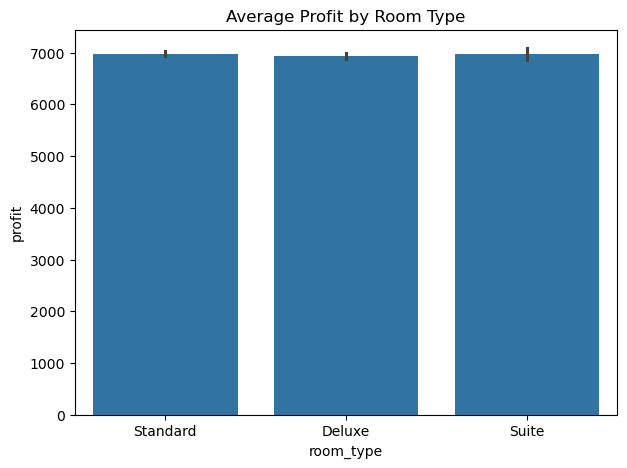

In [669]:
plt.figure(figsize=(7,5))
sns.barplot(x='room_type', y='profit', data=df)
plt.title("Average Profit by Room Type")
plt.show()

## Coupon Usage Analysis

In this section, we analyze how often customers use coupons when making hotel bookings.

Coupons and discounts are commonly used by online travel platforms to attract customers and encourage more bookings. By examining coupon usage, we can understand how many customers take advantage of these offers and whether promotional strategies are being widely used.

This analysis helps identify the role of coupons in the booking process and provides insight into how promotional campaigns may influence customer behavior and booking decisions.

In [670]:
#Coupon Usage Analysis
df['Coupon USed?'].value_counts()


Coupon USed?
No     23807
Yes     6193
Name: count, dtype: int64

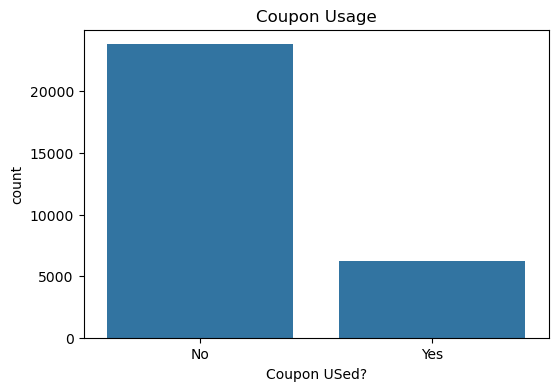

In [671]:
plt.figure(figsize=(6,4))
sns.countplot(x='Coupon USed?', data=df)
plt.title("Coupon Usage")
plt.show()

## Cashback Distribution

In this section, we look at how cashback offers are distributed across bookings.

Cashback is often used by online travel platforms as a promotional incentive to attract customers and encourage more bookings. By analyzing the distribution of cashback values, we can understand how frequently cashback is used and the typical cashback amounts offered to customers.

This analysis helps us identify whether cashback is commonly used in bookings and how large these incentives usually are. Understanding cashback patterns can help the platform design better promotional strategies that attract customers while still maintaining profitability.

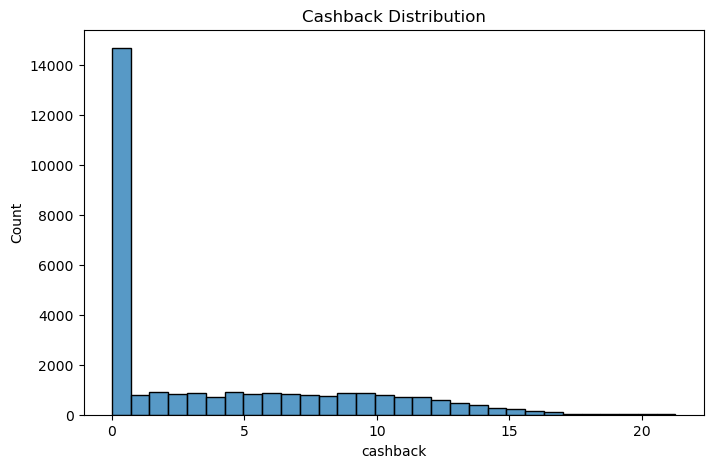

In [672]:
plt.figure(figsize=(8,5))
sns.histplot(df['cashback'], bins=30)
plt.title("Cashback Distribution")
plt.show()

**Observation:**  
Most bookings appear to receive smaller cashback amounts, while higher cashback values occur less frequently. This suggests that cashback is generally used as a small incentive rather than a large discount.

## Top Cities by Bookings

In this section, we analyze which cities have the highest number of hotel bookings in the dataset.

Understanding booking patterns across cities helps identify the most popular travel destinations on the platform. Some cities may attract more bookings due to tourism, business travel, events, or better hotel availability.

By identifying the top cities with the highest booking volumes, the platform can better understand customer travel preferences and focus marketing efforts, promotions, and partnerships in high-demand locations.

In [673]:
#Top Cities By Bookings
df['city'].value_counts().head(10)

city
Chicago          3059
Los Angeles      3040
Las Vegas        3035
San Francisco    3032
Orlando          3015
New York         2993
Boston           2992
Miami            2959
Seattle          2940
Dallas           2935
Name: count, dtype: int64

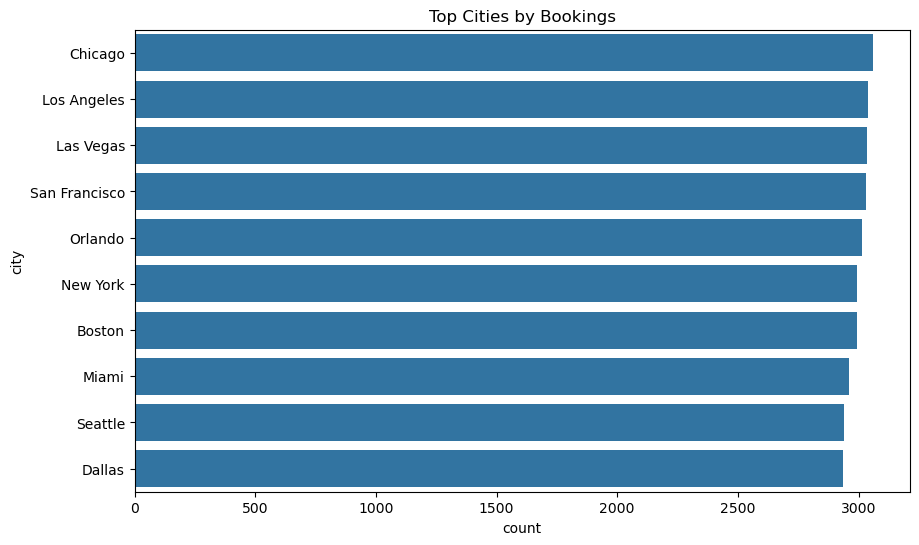

In [674]:
plt.figure(figsize=(10,6))
sns.countplot(y='city', data=df, order=df['city'].value_counts().index[:10])
plt.title("Top Cities by Bookings")
plt.show()

**Observation:**  
A few cities account for a large portion of total bookings, suggesting that travel demand is concentrated in certain popular destinations. These cities likely attract more travelers due to tourism, business activities, or better hotel availability.